# SMS Spam Detection Project
## Motivation
In today’s world, our inboxes are being flooded with spam emails and text messages, consisting of commercial advertisements, antivirus warning, sweepstakes winners, and many other types of money scams. Those who are regularly impacted by spam messages are the majority of the digital communications’ users, ranging from individuals to even businesses and organizations. 
For some people who are familiar and have many encounters, ignoring and filtering these spam messages are not a big issue. However, for many others, clicking into a malicious link which often sounds urgent and appealing can seriously infect their devices with malware. The effects of spam do not stop here. As spam messages also reach businesses and organizations, this wastes time and reduces productivity, as users must spend valuable time identifying legitimate messages instead of focusing on their actual work. As a result, a financial loss naturally follows a decline in productivity, since more resources will be spent on filtering out these messages. This is why a solution is required to detect whether a message is spam or not.
## Methodology to Detect Spam
The idea of this system is based on the idea of most spam messages often contain certain keywords or phrases that can be distinguished, such as ‘cheap’, ‘sale’, ‘act now’, ‘make money’, ‘final notice’, ‘winner’, ‘congratulation’, etc. Our model can be trained to detect these types of words and even phrases in the sentences, so the message can be classified as spam or ham – not spam. Since not all classification models can be applied in this challenge since most are based on numerical data and not text data, a data type conversion from text to numerical will be required. And SVM will be used in this project since it works best for most classification problems.
In our model, just counting the frequency of words won’t be sufficient, since words like ‘the’, ‘and’ will dominate the datasets, drowning important words like ‘money’, ‘act now’, ‘urgent,’ etc. That is why we have to apply weights on the important words that would signal a spam message. For this, we will implement both Count Vectorization and Term Frequency- Inverse Document Frequency (TF-IDF). We will convert the text data into numerical data using each method and compare the score for each. 

•	Count Vectorization: this method creates a vocabulary of all unique words in a dataset and simply counts how many times each word appears in a specific message. 
$$CV(t, d) = \text{number of times term } t \text{ appears in document } d$$
•	TF-IDF: the method starts by counting the words (Term Frequency), but then it multiplies that count by a penalty factor (Inverse Document Frequency). The penalty factor looks at the entire dataset. If a word appears in almost every single message (like "the" or "you"), its penalty is huge, and its final score is crushed down near zero. If a word appears a lot in one message, but rarely in the overall dataset (like "urgent" or "jackpot"), it gets a massive score.
$$TF(t, d) = \frac{\text{number of times } t \text{ appears in } d}{\text{total number of terms in } d}$$

$$IDF(t) = \log\left(\frac{\text{total number of documents}}{{\text{number of documents containing } t}}\right)$$

$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

## Support Vector Machines
Once the text data has been converted into numerical vectors using either Count Vectorization or TF-IDF, SVM can now operate on it. SVM works by finding the optimal hyperplane that best separates the data points of two classes — in this case, spam and ham. The hyperplane is chosen such that the margin, which is the distance between the hyperplane and the nearest data points from each class (called support vectors), is maximized.
The optimal hyperplane satisfies:

$$\max \frac{2}{||\mathbf{w}||}$$

Subject to:

$$y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1, \quad \forall i$$

where $\mathbf{w}$ is the weight vector, $b$ is the bias, $\mathbf{x}_i$ are the data points, and $y_i \in \{-1, +1\}$ are the class labels.
This maximization is what makes SVM particularly robust and resistant to overfitting. In high-dimensional spaces — which is exactly our situation, since each unique word becomes its own dimension after vectorization — SVM performs especially well, making it a natural fit for text classification tasks like spam detection.


## Steps to Implement Spam Detection using SVM
### Phase 1: Data Acquisition and Proprocessing

In [15]:
import numpy as np
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords 
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC # Specific SVM import
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# load the dataset
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [17]:
# clean the dataset
df = df.drop(['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'], axis  = 1) # drop the columns containing null values 
df = df.rename(columns = {'v1': 'label', 'v2': 'Text'}) # rename the columns
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1}) # encode text labels into numeric form
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


Class counts: 
label
ham     4825
spam     747
Name: count, dtype: int64

Class percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


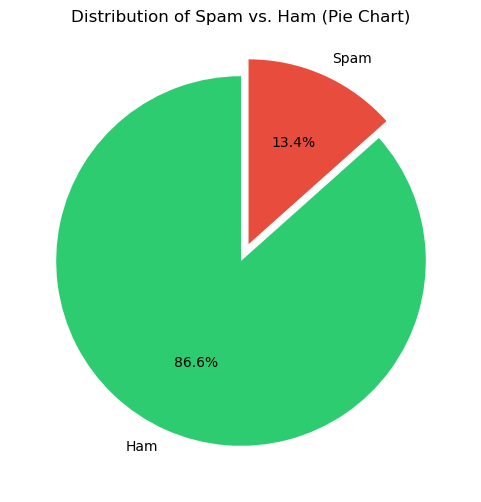

In [26]:
# print the raw numbers
print("Class counts: ")
print(df['label'].value_counts())
print("\nClass percentage:")
print(df['label'].value_counts(normalize=True)*100)
# Visualize with a Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    df['label'].value_counts(), 
    labels=['Ham', 'Spam'], 
    autopct='%1.1f%%', 
    colors=['#2ecc71', '#e74c3c'], 
    startangle=90,
    explode=(0, 0.1) # This slightly pops the "Spam" slice out for emphasis
)
plt.title('Distribution of Spam vs. Ham (Pie Chart)')
plt.show()

In [18]:
# Initialize NLP tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
# clean/preprocess the data
def clean_text(text):
    # Remove non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    # convert to lower case
    text = text.lower()
    # split into words
    words = text.split()
    # remove stop words and stem remaining words
    cleaned_words = []
    for w in words:
        if w not in stop_words:
            cleaned_words.append(stemmer.stem(w))
    # rejoin words back into string
    string = ' '.join(cleaned_words)
    return string

In [19]:
df['Text'] = df['Text'].apply(clean_text)
df.head()

,label,Text,label_enc
0,ham,go jurong point crazi avail bugi n great world...,0
1,ham,ok lar joke wif u oni,0
2,spam,free entri wkli comp win fa cup final tkt st m...,1
3,ham,u dun say earli hor u c alreadi say,0
4,ham,nah think goe usf live around though,0


In [21]:
# split data into traning and testing 
X_train, X_test, y_train, y_test= train_test_split(
    df['Text'],
    df['label_enc'],
    test_size = 0.2,
    random_state = 42, 
    stratify = df['label_enc']
)
print(f"Data split complete: {len(X_train)} training samples, {len(X_test)} testing samples.")

Data split complete: 4457 training samples, 1115 testing samples.


## Phase 2: Vectorization

In [ ]:
# First instance 